# Symmetry-aware mode selection

`bfeax` can exploit density symmetries to skip zero modes during both
**build** (angular projection, Poisson solve, spline fitting) and
**force evaluation**.

Four symmetry classes are supported:

| `symmetry` | Modes kept ($\ell_{\max}{=}8$) | Use when |
|---|---|---|
| `"spherical"` | 1 | $\rho = \rho(r)$ |
| `"axisymmetric"` | 9 | $\rho = \rho(r, \theta)$ — cylindrical symmetry about $z$ |
| `"triaxial"` | 15 | Octant symmetry: $\rho(\pm x, \pm y, \pm z) = \rho(x,y,z)$ |
| `None` | 81 | General — all modes, with runtime pruning |

For `from_spheroid`, symmetry is **auto-detected** from the axis ratios
`p` and `q` when not specified.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import time

from bfeax import MultipoleExpansion

## 1. Auto-detection from axis ratios

`from_spheroid` inspects `p` and `q` and picks the tightest symmetry automatically.

In [2]:
grid = dict(r_min=0.01, r_max=300, n_r=128, l_max=8)
nfw = dict(rho0=1.0, alpha=1.0, beta=3.0, gamma=1.0, a=1.0)

configs = [
    ("Spherical",    dict(p=1.0, q=1.0)),
    ("Axisymmetric", dict(p=1.0, q=0.6)),
    ("Triaxial",     dict(p=0.8, q=0.6)),
]

for label, axes in configs:
    exp = MultipoleExpansion.from_spheroid(**nfw, **axes, **grid)
    print(f"{label:14s}  (p={axes['p']}, q={axes['q']})  →  "
          f"symmetry={exp.symmetry!r:16s}  modes={len(exp._lm_keys)}")

Spherical       (p=1.0, q=1.0)  →  symmetry='spherical'       modes=1
Axisymmetric    (p=1.0, q=0.6)  →  symmetry='axisymmetric'    modes=9
Triaxial        (p=0.8, q=0.6)  →  symmetry='triaxial'        modes=15


## 2. Explicit symmetry with `from_density`

For `from_density`, symmetry is not auto-detected — the user specifies it.
This is useful when you know the density has a particular symmetry but `bfeax`
can't infer it from the function signature.

In [3]:
def triaxial_nfw(x, y, z):
    """Triaxial NFW with axis ratios p=0.8, q=0.6."""
    s2 = x**2 + (y / 0.8)**2 + (z / 0.6)**2
    s = jnp.sqrt(s2)
    return 1.0 / (s * (1.0 + s)**2)

# Without symmetry: computes all 81 modes
exp_all = MultipoleExpansion.from_density(
    triaxial_nfw, r_min=0.01, r_max=300, n_r=128, l_max=8,
)
print(f"No symmetry:  {len(exp_all._lm_keys)} modes")

# With triaxial symmetry: only 15 modes
exp_tri = MultipoleExpansion.from_density(
    triaxial_nfw, r_min=0.01, r_max=300, n_r=128, l_max=8,
    symmetry="triaxial",
)
print(f"Triaxial:     {len(exp_tri._lm_keys)} modes")

# Verify they agree
x_test = jnp.array([1.0, 3.0, 10.0])
y_test = jnp.array([0.5, 1.5, 4.0])
z_test = jnp.array([0.3, 0.8, 2.0])

phi_all = exp_all(x_test, y_test, z_test)
phi_tri = exp_tri(x_test, y_test, z_test)
print(f"\nPotential max relative error: {float(jnp.max(jnp.abs(phi_all - phi_tri) / jnp.abs(phi_all))):.1e}")

No symmetry:  81 modes
Triaxial:     15 modes

Potential max relative error: 5.6e-16


## 3. Build-time speedup

The main benefit of specifying symmetry is faster builds — fewer modes means
less work in the angular projection einsum, Poisson solver, and spline fitting.

We benchmark `from_density` (where the speedup is most visible) and
`from_spheroid` across all symmetry types.

In [4]:
# --- from_density benchmark (triaxial NFW) ---

symmetries = [None, "triaxial"]
n_iter = 5

print("=== from_density (triaxial NFW, l_max=8, n_r=128) ===\n")
print(f"{'symmetry':<15} {'modes':>6} {'build time':>12} {'speedup':>8}")
print("-" * 45)

build_times = {}
for sym in symmetries:
    # JIT warmup
    MultipoleExpansion.from_density(
        triaxial_nfw, r_min=0.01, r_max=300, n_r=128, l_max=8,
        symmetry=sym,
    )
    ts = []
    for _ in range(n_iter):
        t0 = time.perf_counter()
        exp = MultipoleExpansion.from_density(
            triaxial_nfw, r_min=0.01, r_max=300, n_r=128, l_max=8,
            symmetry=sym,
        )
        ts.append(time.perf_counter() - t0)
    med = np.median(ts)
    build_times[str(sym)] = med
    n_modes = len(exp._lm_keys)
    speedup = build_times["None"] / med if "None" in build_times else 1.0
    print(f"{str(sym):<15} {n_modes:>6} {med*1e3:>10.1f}ms {speedup:>7.1f}x")

=== from_density (triaxial NFW, l_max=8, n_r=128) ===

symmetry         modes   build time  speedup
---------------------------------------------
None                81      148.8ms     1.0x
triaxial            15       55.2ms     2.7x


In [5]:
# --- from_spheroid benchmark (all symmetry types) ---

print("\n=== from_spheroid (NFW, l_max=8, n_r=128) ===\n")
print(f"{'config':<30} {'modes':>6} {'build time':>12}")
print("-" * 52)

spheroid_configs = [
    ("Triaxial (auto)",       dict(p=0.8, q=0.6)),
    ("Triaxial (sym=None)",   dict(p=0.8, q=0.6, symmetry=None)),
    ("Axisymmetric (auto)",   dict(p=1.0, q=0.6)),
    ("Spherical (auto)",      dict(p=1.0, q=1.0)),
]

for label, kw in spheroid_configs:
    # JIT warmup
    MultipoleExpansion.from_spheroid(**nfw, **grid, **kw)
    ts = []
    for _ in range(20):
        t0 = time.perf_counter()
        exp = MultipoleExpansion.from_spheroid(**nfw, **grid, **kw)
        ts.append(time.perf_counter() - t0)
    med = np.median(ts)
    n_modes = len(exp._lm_keys)
    print(f"{label:<30} {n_modes:>6} {med*1e3:>10.1f}ms")


=== from_spheroid (NFW, l_max=8, n_r=128) ===

config                          modes   build time
----------------------------------------------------
Triaxial (auto)                    15        7.4ms
Triaxial (sym=None)                15        5.0ms
Axisymmetric (auto)                 9        5.0ms
Spherical (auto)                    1        3.8ms


## 4. Force evaluation speedup

For force evaluation, symmetry mainly helps the **spherical** case (where
mode pruning already reduces 81 → 1, but symmetry avoids the pruning scan
entirely). For triaxial densities, mode pruning already identifies the
correct 15 nonzero modes at runtime, so specifying symmetry doesn't change
the force speed — but it does avoid computing and storing 66 zero-mode splines.

In [6]:
# Generate test points
rng = np.random.default_rng(42)
N = 10_000
r = np.exp(rng.uniform(np.log(0.1), np.log(20.0), N))
cos_t = rng.uniform(-1.0, 1.0, N)
sin_t = np.sqrt(1.0 - cos_t**2)
phi = rng.uniform(0.0, 2 * np.pi, N)
x_pts = jnp.array(r * sin_t * np.cos(phi))
y_pts = jnp.array(r * sin_t * np.sin(phi))
z_pts = jnp.array(r * cos_t)

force_configs = [
    ("Spherical, sym=None",      dict(p=1.0, q=1.0, symmetry=None)),
    ("Spherical, auto",          dict(p=1.0, q=1.0)),
    ("Axisymmetric, sym=None",   dict(p=1.0, q=0.6, symmetry=None)),
    ("Axisymmetric, auto",       dict(p=1.0, q=0.6)),
    ("Triaxial, sym=None",       dict(p=0.8, q=0.6, symmetry=None)),
    ("Triaxial, auto",           dict(p=0.8, q=0.6)),
]

print(f"{'config':<30} {'modes':>6} {'active':>7} {'force (ms)':>11}")
print("-" * 58)

for label, kw in force_configs:
    exp = MultipoleExpansion.from_spheroid(**nfw, **grid, **kw)

    # Warmup
    for _ in range(5):
        out = exp.force(x_pts, y_pts, z_pts)
        jax.block_until_ready(out)

    # Time
    ts = []
    for _ in range(20):
        t0 = time.perf_counter()
        out = exp.force(x_pts, y_pts, z_pts)
        jax.block_until_ready(out)
        ts.append(time.perf_counter() - t0)

    # Count active modes (after pruning)
    log_r_knots, phi_coeffs, _, _, _ = exp._stacked
    a_c, b_c, c_c, d_c = phi_coeffs
    max_per = np.max(
        np.abs(np.asarray(a_c)) + np.abs(np.asarray(b_c))
        + np.abs(np.asarray(c_c)) + np.abs(np.asarray(d_c)), axis=1)
    n_active = int(np.sum(max_per > 1e-10 * np.max(max_per)))

    print(f"{label:<30} {len(exp._lm_keys):>6} {n_active:>7} "
          f"{np.median(ts)*1e3:>9.2f}ms")

config                          modes  active  force (ms)
----------------------------------------------------------
Spherical, sym=None                 1       1      0.31ms
Spherical, auto                     1       1      0.31ms
Axisymmetric, sym=None              9       5      1.85ms
Axisymmetric, auto                  9       5      1.94ms
Triaxial, sym=None                 15      15      1.44ms
Triaxial, auto                     15      15      1.33ms


## 5. Visualization: which modes are active?

For each symmetry class, we show which $(\ell, m)$ modes are included.

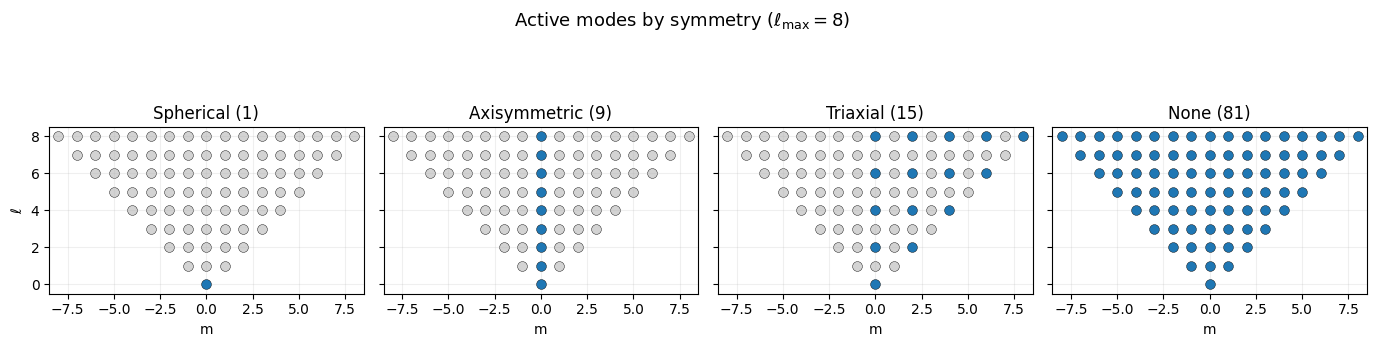

In [7]:
from bfe.potential import _lm_keys

l_max = 8
sym_types = ["spherical", "axisymmetric", "triaxial", None]
titles = ["Spherical (1)", "Axisymmetric (9)", "Triaxial (15)", "None (81)"]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), sharey=True)

for ax, sym, title in zip(axes, sym_types, titles):
    active = set(_lm_keys(l_max, sym))
    all_modes = _lm_keys(l_max, None)

    for l, m in all_modes:
        color = "C0" if (l, m) in active else "lightgray"
        ax.scatter(m, l, c=color, s=50, edgecolors="k", linewidths=0.3,
                   zorder=2 if (l, m) in active else 1)

    ax.set_xlabel("m")
    ax.set_title(title)
    ax.set_xlim(-l_max - 0.5, l_max + 0.5)
    ax.set_ylim(-0.5, l_max + 0.5)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel(r"$\ell$")
fig.suptitle(r"Active modes by symmetry ($\ell_{\max}=8$)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()